In [1]:
# If needed
# !pip install pandas scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np
import re

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ufc_fight_results.csv")

df.head()

,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
0,UFC Fight Night: Dolidze vs. Hernandez,Roman Dolidze vs. Anthony Hernandez,L/W,Middleweight Bout,Submission,4,2:45,5 Rnd (5-5-5-5-5),Herb Dean,Rear Naked Choke,http://ufcstats.com/fight-details/68fe62bac7fd...
1,UFC Fight Night: Dolidze vs. Hernandez,Steve Erceg vs. Ode Osbourne,W/L,Bantamweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Mark Smith,Ben Cartlidge 28 - 29.Eric Colon 28 - 29.Junic...,http://ufcstats.com/fight-details/37d58369782c...
2,UFC Fight Night: Dolidze vs. Hernandez,Iasmin Lucindo vs. Angela Hill,W/L,Women's Strawweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Chris Tognoni,Mike Bell 27 - 30.Sal D'amato 27 - 30.Ben Cart...,http://ufcstats.com/fight-details/646c79a7ecd1...
3,UFC Fight Night: Dolidze vs. Hernandez,Andre Fili vs. Christian Rodriguez,W/L,Featherweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Mike Beltran,Eric Colon 28 - 29.Chris Lee 29 - 28.Anthony M...,http://ufcstats.com/fight-details/98d6771af9b0...
4,UFC Fight Night: Dolidze vs. Hernandez,Miles Johns vs. Jean Matsumoto,L/W,Bantamweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Herb Dean,Mike Bell 28 - 29.Ben Cartlidge 29 - 28.Sal D'...,http://ufcstats.com/fight-details/ed5383b50ffc...


In [4]:
import re

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Ensure column exists
if "method" in df.columns:
    df = df.dropna(subset=["method"])
    df["method_clean"] = df["method"].str.lower()
    df["method_clean"] = df["method_clean"].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
else:
    print("Column 'method' not found. Available columns:", df.columns)

df.head()

,event,bout,outcome,weightclass,method,round,time,time format,referee,details,url,method_clean
0,UFC Fight Night: Dolidze vs. Hernandez,Roman Dolidze vs. Anthony Hernandez,L/W,Middleweight Bout,Submission,4,2:45,5 Rnd (5-5-5-5-5),Herb Dean,Rear Naked Choke,http://ufcstats.com/fight-details/68fe62bac7fd...,submission
1,UFC Fight Night: Dolidze vs. Hernandez,Steve Erceg vs. Ode Osbourne,W/L,Bantamweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Mark Smith,Ben Cartlidge 28 - 29.Eric Colon 28 - 29.Junic...,http://ufcstats.com/fight-details/37d58369782c...,decision unanimous
2,UFC Fight Night: Dolidze vs. Hernandez,Iasmin Lucindo vs. Angela Hill,W/L,Women's Strawweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Chris Tognoni,Mike Bell 27 - 30.Sal D'amato 27 - 30.Ben Cart...,http://ufcstats.com/fight-details/646c79a7ecd1...,decision unanimous
3,UFC Fight Night: Dolidze vs. Hernandez,Andre Fili vs. Christian Rodriguez,W/L,Featherweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Mike Beltran,Eric Colon 28 - 29.Chris Lee 29 - 28.Anthony M...,http://ufcstats.com/fight-details/98d6771af9b0...,decision split
4,UFC Fight Night: Dolidze vs. Hernandez,Miles Johns vs. Jean Matsumoto,L/W,Bantamweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Herb Dean,Mike Bell 28 - 29.Ben Cartlidge 29 - 28.Sal D'...,http://ufcstats.com/fight-details/ed5383b50ffc...,decision split


In [5]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["method_clean"])

print("Feature shape:", X.shape)

Feature shape: (8250, 12)


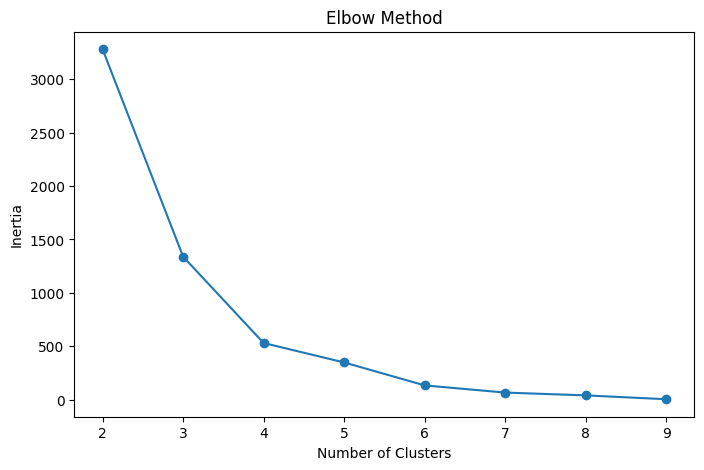

In [6]:
inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

,event,bout,outcome,weightclass,method,round,time,time format,referee,details,url,method_clean,cluster
0,UFC Fight Night: Dolidze vs. Hernandez,Roman Dolidze vs. Anthony Hernandez,L/W,Middleweight Bout,Submission,4,2:45,5 Rnd (5-5-5-5-5),Herb Dean,Rear Naked Choke,http://ufcstats.com/fight-details/68fe62bac7fd...,submission,2
1,UFC Fight Night: Dolidze vs. Hernandez,Steve Erceg vs. Ode Osbourne,W/L,Bantamweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Mark Smith,Ben Cartlidge 28 - 29.Eric Colon 28 - 29.Junic...,http://ufcstats.com/fight-details/37d58369782c...,decision unanimous,0
2,UFC Fight Night: Dolidze vs. Hernandez,Iasmin Lucindo vs. Angela Hill,W/L,Women's Strawweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Chris Tognoni,Mike Bell 27 - 30.Sal D'amato 27 - 30.Ben Cart...,http://ufcstats.com/fight-details/646c79a7ecd1...,decision unanimous,0
3,UFC Fight Night: Dolidze vs. Hernandez,Andre Fili vs. Christian Rodriguez,W/L,Featherweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Mike Beltran,Eric Colon 28 - 29.Chris Lee 29 - 28.Anthony M...,http://ufcstats.com/fight-details/98d6771af9b0...,decision split,3
4,UFC Fight Night: Dolidze vs. Hernandez,Miles Johns vs. Jean Matsumoto,L/W,Bantamweight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Herb Dean,Mike Bell 28 - 29.Ben Cartlidge 29 - 28.Sal D'...,http://ufcstats.com/fight-details/ed5383b50ffc...,decision split,3


In [8]:
score = silhouette_score(X, df["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.9307438573260723


In [9]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center.argsort()[-10:]]
    
    print(f"\nCluster {i} Top Terms:")
    print(top_terms)


Cluster 0 Top Terms:
['dq', 'kotko', 'overturned', 'split', 'stoppage', 'submission', 'tko', 'majority', 'decision', 'unanimous']

Cluster 1 Top Terms:
['split', 'submission', 'unanimous', 'dq', 'continue', 'overturned', 'doctors', 'stoppage', 'tko', 'kotko']

Cluster 2 Top Terms:
['doctors', 'dq', 'kotko', 'majority', 'overturned', 'split', 'stoppage', 'tko', 'unanimous', 'submission']

Cluster 3 Top Terms:
['dq', 'kotko', 'majority', 'overturned', 'stoppage', 'submission', 'tko', 'unanimous', 'decision', 'split']


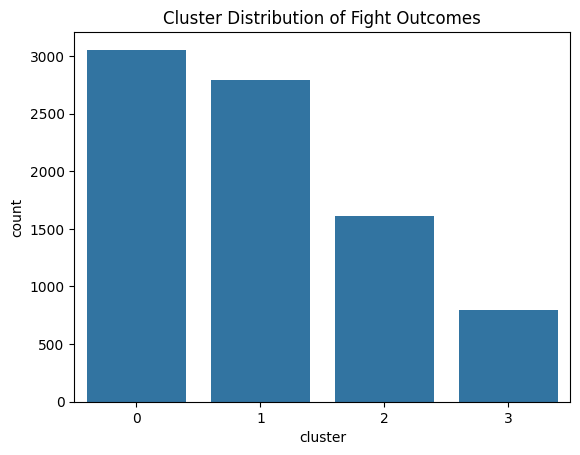

In [10]:
sns.countplot(x="cluster", data=df)
plt.title("Cluster Distribution of Fight Outcomes")
plt.show()

In [11]:
for i in range(k):
    print(f"\nCluster {i} sample methods:")
    print(df[df["cluster"] == i]["method"].head(5).values)


Cluster 0 sample methods:
<ArrowStringArray>
['Decision - Unanimous ', 'Decision - Unanimous ', 'Decision - Unanimous ',
 'Decision - Unanimous ', 'Decision - Unanimous ']
Length: 5, dtype: str

Cluster 1 sample methods:
<ArrowStringArray>
['KO/TKO ', 'KO/TKO ', 'KO/TKO ', 'KO/TKO ', 'KO/TKO ']
Length: 5, dtype: str

Cluster 2 sample methods:
<ArrowStringArray>
['Submission ', 'Submission ', 'Submission ', 'Submission ', 'Submission ']
Length: 5, dtype: str

Cluster 3 sample methods:
<ArrowStringArray>
['Decision - Split ', 'Decision - Split ', 'Decision - Split ',
 'Decision - Split ', 'Decision - Split ']
Length: 5, dtype: str
